In [ ]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from pybaseball import batting_stats
import logging
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from arviz import hdi
from sklearn.metrics import root_mean_squared_error
import scipy.stats as stats
from scipy.special import logit
import matplotlib.patches as mpatches

tf.get_logger().setLevel(logging.FATAL)  # suppress TF warnings

In [2]:
# --- Load data ---
raw_2018 = batting_stats(2018)
raw_2019 = batting_stats(2019)
raw_2021 = batting_stats(2021)
raw_2022 = batting_stats(2022)
raw_2023 = batting_stats(2023)
raw_2024 = batting_stats(2024)
raw_2025 = batting_stats(2025)

# --- Combine ---
raw_data = pd.concat([raw_2018, raw_2019, raw_2021, raw_2022, raw_2023, raw_2024, raw_2025])

# --- Select columns ---
#df = raw_data[["Season", "Name", "Team", "Pos", "Age", "PA", 
#               "AVG", "OBP", "SLG", "OPS", "xBA", "xwOBA", "K%", "Contact%", 
#               "EV", "Barrel%", "HardHit%"]]
df = raw_data[["Season", "Name", "Team", "Age", "PA", "AVG", "xBA"]] #trimming

# --- Filter for players with 500+ PA ---
df = df[df['PA'] >= 500].copy()

#save data
#raw_data.to_csv("C:/Users/Andrew/baseball/data/batting_stats_raw_2018_2025.csv", index=False)
#df.to_csv("C:/Users/Andrew/baseball/data/batting_stats_filtered_2018_2025.csv", index=False)

In [3]:
print(f"Total rows: {len(df)}")
print(f"Total players: {df['Name'].nunique()}")
print(f"Seasons: {sorted(df['Season'].unique().tolist())}")

Total rows: 946
Total players: 377
Seasons: [2018, 2019, 2021, 2022, 2023, 2024, 2025]


In [5]:
# --- Sort by player and season ---
df = df.sort_values(['Name', 'Season']).reset_index(drop=True)

# --- Create next year AVG column ---
df['AVG_next'] = df.groupby('Name')['AVG'].shift(-1)

# --- Split into training and prediction sets ---
model_df = df[df['AVG_next'].notna()].copy()  # Training set - has AVG_next
model_df = model_df[model_df['Season'] != 2025].copy()  # #removing 2025 data - used to predict 2026 avg
df_2025 = df[df['Season'] == 2025].copy()     # Validation set - 2025 data, no AVG_next

# --- Define features and target ---
model_df['Age2'] = model_df['Age'] **2 #add age^2
df_2025['Age2'] = df_2025['Age'] **2 #add age^2

features = ["Age2", "AVG", "xBA"] # chosen through LOOCV
target = 'AVG_next'

# --- Standardize Features ---
scaler_X = StandardScaler()
X = scaler_X.fit_transform(model_df[features]) #standardize all features
X_2025 = scaler_X.transform(df_2025[features])  # use same scaler
y = model_df[target].values # not standardized but bounded inside [0,1] (on same scale)


print(f"Seasons in model_df: {sorted(model_df['Season'].unique().tolist())}")
print(f"Any nulls in X: {np.isnan(X).any()}")
print(f"Any nulls in X_2025: {np.isnan(X_2025).any()}")
print(f"Training rows: {len(model_df)}")
print(f"Players to predict: {len(df_2025)}")
print(f"y mean: {y.mean():.3f}, y std: {y.std():.3f}")
print(model_df[["Season", "Name",'Age', "AVG", "xBA", "AVG_next"]].head(10))

Seasons in model_df: [2018, 2019, 2021, 2022, 2023, 2024]
Any nulls in X: False
Any nulls in X_2025: False
Training rows: 569
Players to predict: 145
y mean: 0.263, y std: 0.027
    Season             Name  Age    AVG    xBA  AVG_next
2     2021      Aaron Judge   29  0.287  0.302     0.311
3     2022      Aaron Judge   30  0.311  0.304     0.322
4     2024      Aaron Judge   32  0.322  0.305     0.331
8     2019     Adam Frazier   27  0.278  0.275     0.305
9     2021     Adam Frazier   29  0.305  0.286     0.238
11    2018       Adam Jones   32  0.281  0.268     0.260
14    2023  Adley Rutschman   25  0.277  0.289     0.250
16    2021    Adolis Garcia   28  0.243  0.216     0.250
17    2022    Adolis Garcia   29  0.250  0.242     0.245
18    2023    Adolis Garcia   30  0.245  0.245     0.224


In [6]:
# --- Check Correlation between terms ---
print(pd.DataFrame(X, columns=features).corr())

# Used LOOCV to find best feature combo

          Age2       AVG       xBA
Age2  1.000000 -0.019955 -0.003858
AVG  -0.019955  1.000000  0.804922
xBA  -0.003858  0.804922  1.000000


In [7]:
# --- Check boundaries for beta distribution ---
# (it breaks at the edges)
print(f"y == 0: {(y == 0).sum()}")
print(f"y == 1: {(y == 1).sum()}")

y == 0: 0
y == 1: 0


In [19]:
#--- Compute logit of observed mean ---
observed_mean = y.mean() - .06
logit_mean = logit(observed_mean)

print(f"Observed mean:          {observed_mean:.3f}")
print(f"Logit of observed mean: {logit_mean:.3f}")

Observed mean:          0.203
Logit of observed mean: -1.369


In [20]:
# --- Model ---
with pm.Model(coords={"features": features}) as model:

    # --- Create Data containers ---
    X_data = pm.Data('X_data', X)
    y_data = pm.Data('y_data', y)

    # --- Create Model ---
    alpha = pm.Normal('alpha', mu=logit_mean, sigma=0.33)
    betas = pm.Normal('betas', mu=0, sigma=1.0, dims="features")

    mu = pm.Deterministic('mu', pm.math.sigmoid(alpha + (X_data * betas).sum(axis=1)))
    kappa = pm.HalfNormal('kappa', sigma=20)

    # --- Likelihood ---
    y_obs = pm.Beta('y_obs', mu=mu, nu=kappa, observed=y_data)

    # --- Sample ---
    trace = pm.sample(2000, tune=1500, chains=4, target_accept=0.85, cores=4)

c:\Users\Andrew\anaconda3\envs\python_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, betas, kappa]


Output()

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 103 seconds.


In [21]:
# --- Model ---
with pm.Model(coords={"features": features}) as model:

    # --- Create Data containers ---
    X_data = pm.Data('X_data', X)
    y_data = pm.Data('y_data', y)

    # --- Create Model ---
    alpha = pm.Normal('alpha', mu=logit_mean, sigma=0.33)
    betas = pm.Normal('betas', mu=0, sigma=1.0, dims="features")

    mu = pm.Deterministic('mu', pm.math.sigmoid(alpha + (X_data * betas).sum(axis=1)))
    kappa = pm.HalfNormal('kappa', sigma=20)

    # --- Likelihood ---
    y_obs = pm.Beta('y_obs', mu=mu, nu=kappa, observed=y_data)

    # --- Sample ---
    trace = pm.sample(2000, tune=1500, chains=4, target_accept=0.85, cores=4)

c:\Users\Andrew\anaconda3\envs\python_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, betas, kappa]


Output()

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 119 seconds.


In [22]:
with model:
    prior = pm.sample_prior_predictive(500)
    

Sampling: [alpha, betas, kappa, y_obs]


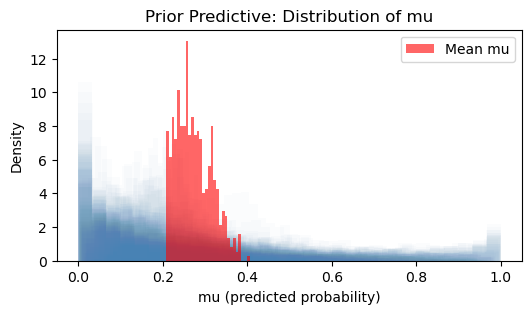

In [23]:
# --- Plot mu prior distribution ---
mu_samples = prior.prior["mu"].values.reshape(-1, X.shape[0])

plt.figure(figsize=(6, 3))
# --- Plot a random subset of 100 draw curves ---
for i in np.random.choice(mu_samples.shape[0], 100, replace=False):
    plt.hist(mu_samples[i], bins=30, alpha=0.02, color="steelblue", density=True)

# --- Plot mean across all draws ---
plt.hist(mu_samples.mean(axis=0), bins=30, alpha=0.6, color="red", density=True, label="Mean mu")
plt.xlabel("mu (predicted probability)")
plt.ylabel("Density")
plt.title("Prior Predictive: Distribution of mu")
plt.legend()
plt.show()

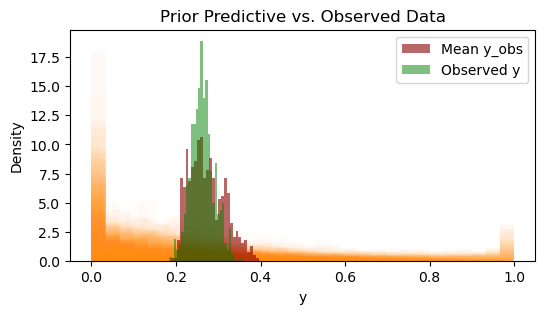

In [24]:
# --- Plot y_obs prior distribution ---
y_prior = prior.prior_predictive["y_obs"].values.reshape(-1, X.shape[0])

plt.figure(figsize=(6, 3))
for i in np.random.choice(y_prior.shape[0], 100, replace=False):
    plt.hist(y_prior[i], bins=30, alpha=0.02, color="darkorange", density=True)

plt.hist(y_prior.mean(axis=0), bins=30, alpha=0.6, color="darkred", density=True, label="Mean y_obs")

plt.hist(y, bins=30, alpha=0.5, color="green", density=True, label="Observed y")
plt.xlabel("y")
plt.ylabel("Density")
plt.title("Prior Predictive vs. Observed Data")
plt.legend()
plt.show()

In [25]:
print(f"Prior mu mean:        {mu_samples.mean():.3f}")
print(f"Prior y_obs mean:     {y_prior.mean():.3f}")
print(f"Observed y mean:      {y.mean():.3f}")

Prior mu mean:        0.273
Prior y_obs mean:     0.273
Observed y mean:      0.263


In [26]:
az.summary(trace, var_names=['alpha', 'betas', 'kappa'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-1.031,0.007,-1.043,-1.018,0.000,0.00,9400.0,5476.0,1.0
betas[Age2],-0.007,0.007,-0.020,0.004,0.000,0.00,9834.0,5627.0,1.0
betas[AVG],0.032,0.011,0.010,0.053,0.000,0.00,6148.0,5644.0,1.0
betas[xBA],0.033,0.011,0.012,0.054,0.000,0.00,5857.0,5397.0,1.0
kappa,204.434,10.301,185.845,223.960,0.109,0.12,8919.0,6129.0,1.0


In [27]:
# --- Test HDI coverage of 0 ---
for i, feature in enumerate(features):
    row = az.summary(trace, var_names=['betas']).iloc[i]
    contains_zero = row['hdi_3%'] < 0 < row['hdi_97%']
    zero_msg = " ⚠️ HDI contains zero" if contains_zero else ""
    print(f"{feature:12s}  mean={row['mean']:+.4f}  hdi=[{row['hdi_3%']:+.4f}, {row['hdi_97%']:+.4f}]{zero_msg}")

Age2          mean=-0.0070  hdi=[-0.0200, +0.0040] ⚠️ HDI contains zero
AVG           mean=+0.0320  hdi=[+0.0100, +0.0530]
xBA           mean=+0.0330  hdi=[+0.0120, +0.0540]


In [28]:
with model:
    pm.set_data({
        'X_data': X_2025,
        'y_data': np.full(len(df_2025), 0.111)
    })
    ppc_2025 = pm.sample_posterior_predictive(trace)

# --- Extract Predictions ---
pred_samples = ppc_2025.posterior_predictive['y_obs'].values.reshape(-1, len(df_2025))
print(f"pred_samples shape: {pred_samples.shape}")

hdi_vals = hdi(pred_samples, hdi_prob=0.94)
df_2025['predicted_AVG'] = pred_samples.mean(axis=0)
df_2025['pred_hdi_low'] = hdi_vals[:, 0]
df_2025['pred_hdi_high'] = hdi_vals[:, 1]

df_2025[['Season', 'Name','Age', 'AVG', 'xBA', 'predicted_AVG', 'pred_hdi_low', 'pred_hdi_high']]\
      .sort_values('predicted_AVG', ascending=False)\
      .head(20)

Sampling: [y_obs]


Output()

pred_samples shape: (8000, 145)


C:\Users\Andrew\AppData\Local\Temp\ipykernel_18348\1623351812.py:12: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_vals = hdi(pred_samples, hdi_prob=0.94)


,Season,Name,Age,AVG,xBA,predicted_AVG,pred_hdi_low,pred_hdi_high
5,2025,Aaron Judge,33,0.331,0.300,0.287479,0.227542,0.347092
97,2025,Bo Bichette,27,0.311,0.295,0.283998,0.226084,0.343881
884,2025,Vladimir Guerrero Jr.,26,0.292,0.300,0.281771,0.221795,0.340663
365,2025,Jacob Wilson,23,0.311,0.277,0.280366,0.221049,0.338590
701,2025,Nico Hoerner,28,0.297,0.292,0.279130,0.219752,0.337871
305,2025,George Springer,35,0.309,0.291,0.278611,0.221932,0.338608
101,2025,Bobby Witt Jr.,25,0.295,0.285,0.278416,0.221472,0.337690
568,2025,Luis Arraez,28,0.292,0.287,0.276427,0.214627,0.331525
923,2025,Yandy Diaz,33,0.300,0.286,0.276062,0.215487,0.333674
405,2025,Jeremy Pena,27,0.304,0.270,0.275119,0.216023,0.333554


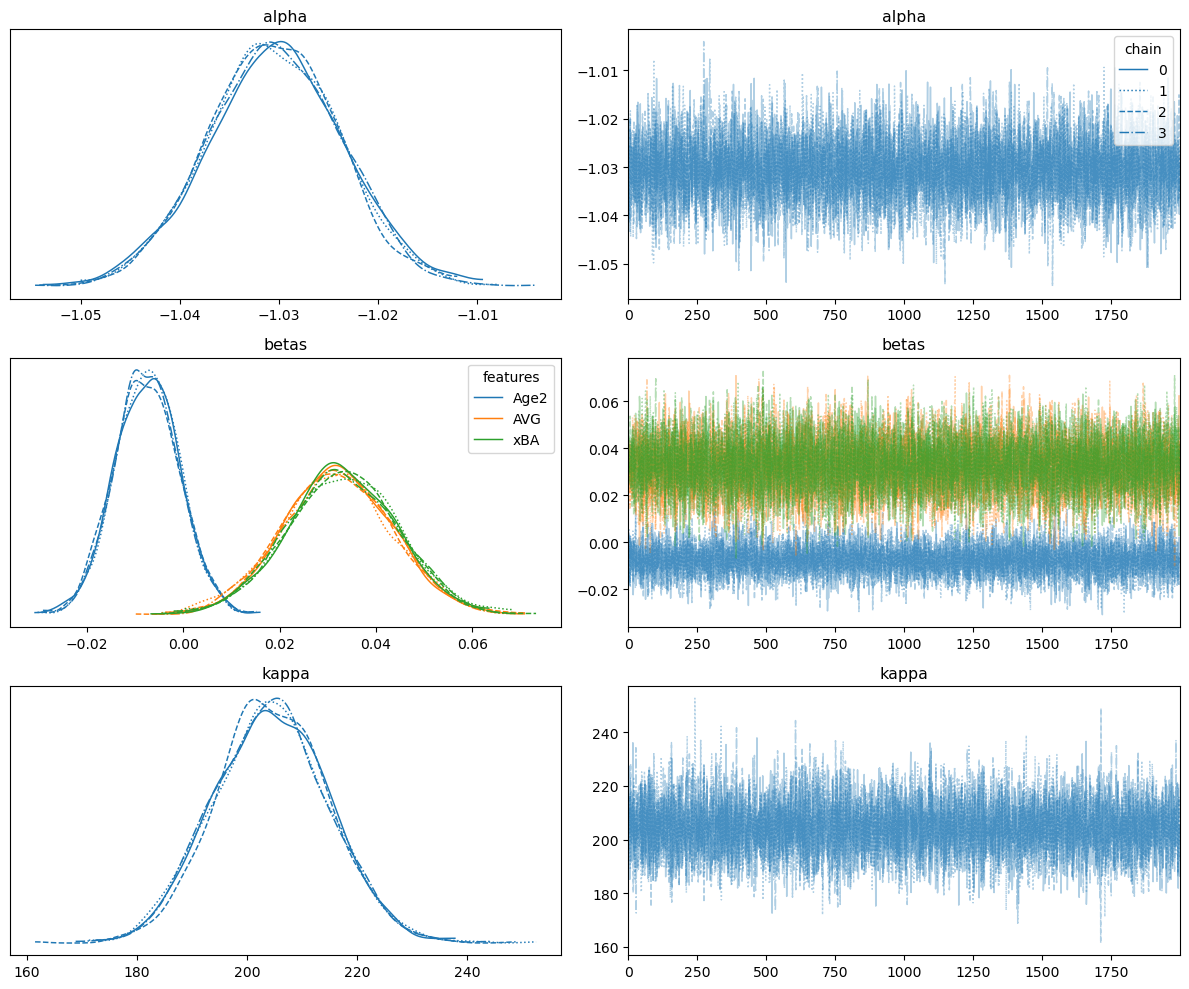

In [29]:
az.plot_trace(trace, var_names=['alpha', 'betas', 'kappa'], 
              figsize=(12, 10), legend=True)
plt.tight_layout()
plt.show()

Sampling: [y_obs]


Output()

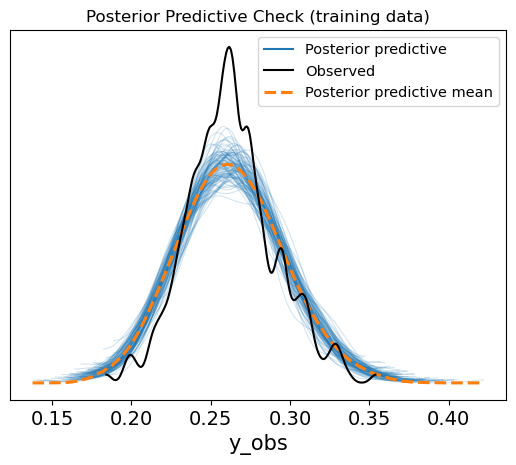

In [31]:
# --- Regenerate ppc on training data ---
with model:
    pm.set_data({'X_data': X, 'y_data': y})
    ppc_train = pm.sample_posterior_predictive(trace)

# --- Olot against real observed values ---
az.plot_ppc(ppc_train, num_pp_samples=100)
plt.title('Posterior Predictive Check (training data)')
plt.show()

C:\Users\Andrew\AppData\Local\Temp\ipykernel_18348\4204542279.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


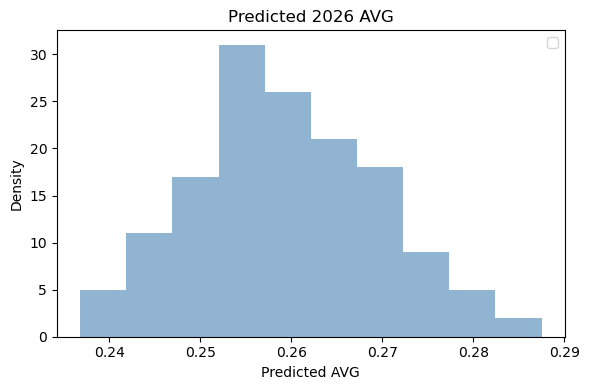

In [39]:
# --- Predicted vs Actual 2025 AVG ---
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(df_2025['predicted_AVG'], alpha=0.6, color='steelblue')

min_val = df_2025['predicted_AVG'].min()
max_val = df_2025['predicted_AVG'].max()

ax.set_xlabel('Predicted AVG')
ax.set_ylabel('Density')
ax.set_title('Predicted 2026 AVG')
ax.legend()

plt.tight_layout()
plt.show()

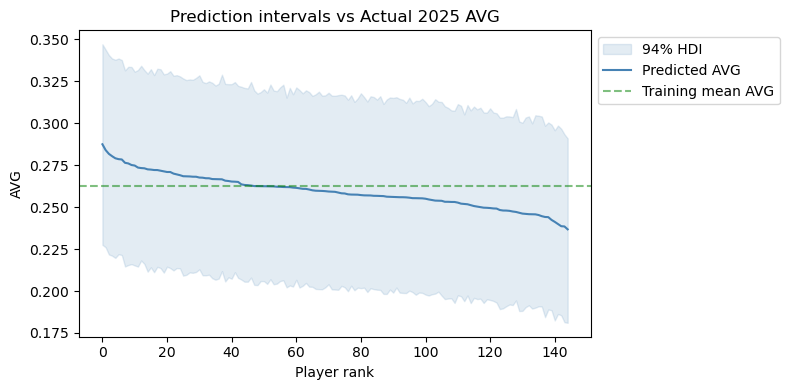

In [40]:
# --- Prediction intervals vs Actual 2025 AVG ---
fig, ax = plt.subplots(figsize=(8, 4))

df_sorted = df_2025.sort_values('predicted_AVG', ascending=False).reset_index(drop=True)

ax.fill_between(
    range(len(df_sorted)),
    df_sorted['pred_hdi_low'],
    df_sorted['pred_hdi_high'],
    alpha=0.15, color='steelblue', label='94% HDI'
)

ax.plot(range(len(df_sorted)), df_sorted['predicted_AVG'],
        color='steelblue', linewidth=1.5, label='Predicted AVG')

ax.axhline(y.mean(), color='green', linestyle='--', alpha=0.5, label='Training mean AVG')

ax.set_xlabel('Player rank')
ax.set_ylabel('AVG')
ax.set_title('2026 Prediction Interval')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

In [42]:
with model:
    pm.set_data({
        'X_data': X_2025,
        'y_data': np.full(len(df_2025), 0.111)
    })
    ppc_2024 = pm.sample_posterior_predictive(trace)

# extract predictions
pred_samples = ppc_2025.posterior_predictive['y_obs'].values.reshape(-1, len(df_2025))
print(f"pred_samples shape: {pred_samples.shape}")

hdi_vals = hdi(pred_samples, hdi_prob=0.94)
df_2025['predicted_AVG'] = pred_samples.mean(axis=0)
df_2025['pred_hdi_low'] = hdi_vals[:, 0]
df_2025['pred_hdi_high'] = hdi_vals[:, 1]

df_2025[['Name', 'Age','AVG', 'xBA', 'predicted_AVG', 'pred_hdi_low', 'pred_hdi_high']]\
      .sort_values('predicted_AVG', ascending=False)\
      .head(20)

Sampling: [y_obs]


Output()

pred_samples shape: (8000, 145)


C:\Users\Andrew\AppData\Local\Temp\ipykernel_18348\2103604737.py:12: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_vals = hdi(pred_samples, hdi_prob=0.94)


,Name,Age,AVG,xBA,predicted_AVG,pred_hdi_low,pred_hdi_high
5,Aaron Judge,33,0.331,0.300,0.287479,0.227542,0.347092
97,Bo Bichette,27,0.311,0.295,0.283998,0.226084,0.343881
884,Vladimir Guerrero Jr.,26,0.292,0.300,0.281771,0.221795,0.340663
365,Jacob Wilson,23,0.311,0.277,0.280366,0.221049,0.338590
701,Nico Hoerner,28,0.297,0.292,0.279130,0.219752,0.337871
305,George Springer,35,0.309,0.291,0.278611,0.221932,0.338608
101,Bobby Witt Jr.,25,0.295,0.285,0.278416,0.221472,0.337690
568,Luis Arraez,28,0.292,0.287,0.276427,0.214627,0.331525
923,Yandy Diaz,33,0.300,0.286,0.276062,0.215487,0.333674
405,Jeremy Pena,27,0.304,0.270,0.275119,0.216023,0.333554


In [43]:
# --- Explore AVG percentiles ---
p50 = np.percentile(df["AVG"],50)
p75 = np.percentile(df["AVG"],75)
p90 = np.percentile(df["AVG"],90)
p95 = np.percentile(df["AVG"],95)
print(p50)
print(p75)
print(p90)
print(p95)

0.261
0.279
0.297
0.309


In [ ]:
# --- Function to call players prediction ---

def get_AVG(player_name):
    name_col = "Name"
    age_col = "Age"
    avg_col = "AVG"
    pred_avg_col = "predicted_AVG"

    player_row = df_2025[df_2025[name_col] == player_name]

    if player_row.empty:
        print(f"No data found for {player_name}")
        return

    player_row = player_row.iloc[0]

    # Create a clean table
    table = pd.DataFrame({
        "Player": [player_name],
        "Age": [player_row[age_col]],
        "AVG": [player_row[avg_col]],
        "Predicted AVG": [player_row[pred_avg_col]]
    })

    # Optional: format decimals (important for batting average readability)
    table["AVG"] = table["AVG"].map(lambda x: f"{x:.3f}")
    table["Predicted AVG"] = table["Predicted AVG"].map(lambda x: f"{x:.3f}")

    print(table.to_string(index=False))

In [58]:
get_AVG("Mookie Betts")

      Player  Age   AVG Predicted AVG
Mookie Betts   32 0.258         0.261


In [54]:
# --- Investingating biggest movers ---
df_2025['avg_change'] = df_2025['predicted_AVG'] - df_2025['AVG']

biggest_changes = (
    df_2025[['Name', 'Age', 'AVG', 'predicted_AVG', 'pred_hdi_low', 'pred_hdi_high', 'avg_change']]
    .assign(abs_change=df_2025['avg_change'].abs())
    .sort_values('abs_change', ascending=False)
    .drop(columns='abs_change')
)

top_gainers = biggest_changes[biggest_changes['avg_change'] > 0].head(10)
top_losers  = biggest_changes[biggest_changes['avg_change'] < 0].head(10)

print("=== TOP GAINERS (Predicted AVG increase) ===")
print(top_gainers.to_string(index=False, float_format='{:.3f}'.format))

print("\n=== TOP LOSERS (Predicted AVG decrease) ===")
print(top_losers.to_string(index=False, float_format='{:.3f}'.format))

=== TOP GAINERS (Predicted AVG increase) ===
           Name  Age   AVG  predicted_AVG  pred_hdi_low  pred_hdi_high  avg_change
     Oneil Cruz   26 0.200          0.237         0.181          0.291       0.037
  Anthony Volpe   24 0.212          0.241         0.182          0.296       0.029
Agustin Ramirez   23 0.231          0.256         0.202          0.316       0.025
   Ryan McMahon   30 0.214          0.239         0.186          0.297       0.025
     Joey Ortiz   26 0.230          0.251         0.193          0.308       0.021
       Jo Adell   26 0.236          0.257         0.202          0.316       0.021
    Matt McLain   25 0.220          0.240         0.186          0.299       0.020
 Salvador Perez   35 0.236          0.255         0.198          0.313       0.019
   Luis Rengifo   28 0.238          0.257         0.198          0.312       0.019
   Willy Adames   29 0.225          0.242         0.189          0.299       0.017

=== TOP LOSERS (Predicted AVG decrease) =

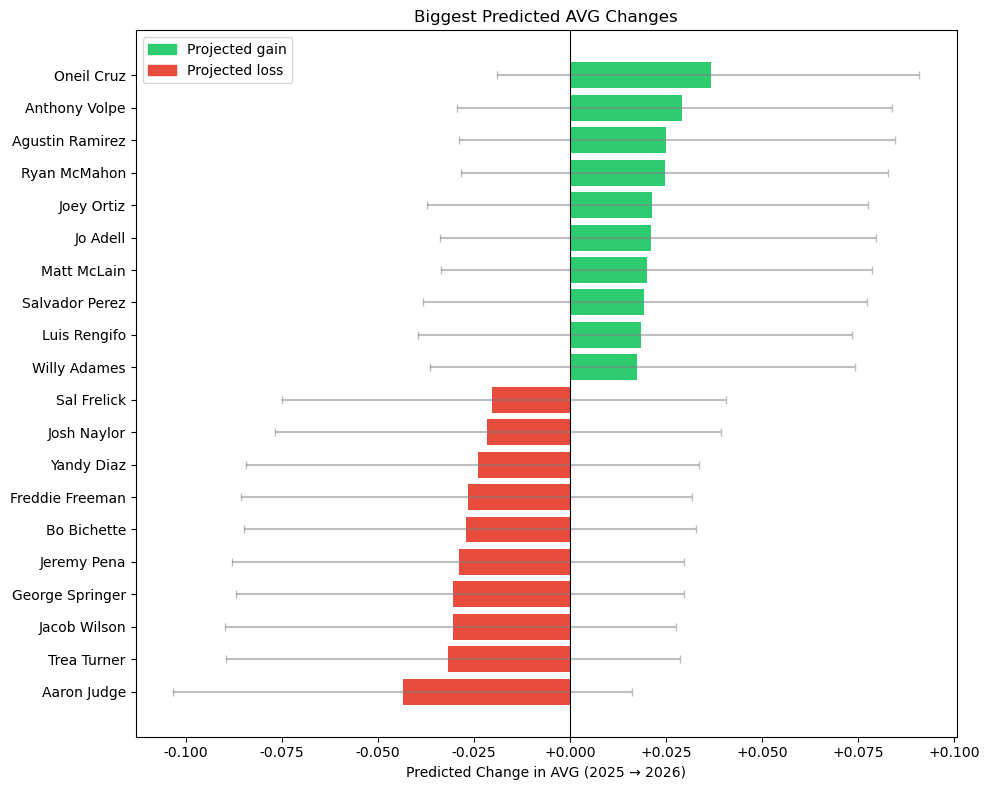

In [56]:
# --- Plotting biggest movers ---

plot_df = pd.concat([top_gainers.head(10), top_losers.head(10)]).sort_values('avg_change')

colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in plot_df['avg_change']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(plot_df['Name'], plot_df['avg_change'], color=colors)

# --- Add HDI error bars ---
ax.errorbar(
    plot_df['avg_change'],
    range(len(plot_df)),
    xerr=[
        plot_df['avg_change'] - (plot_df['pred_hdi_low'] - plot_df['AVG']),
        (plot_df['pred_hdi_high'] - plot_df['AVG']) - plot_df['avg_change']
    ],
    fmt='none', color='gray', alpha=0.5, capsize=3
)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Predicted Change in AVG (2025 → 2026)')
ax.set_title('Biggest Predicted AVG Changes')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.3f}'))


gain_patch = mpatches.Patch(color='#2ecc71', label='Projected gain')
loss_patch = mpatches.Patch(color='#e74c3c', label='Projected loss')
ax.legend(handles=[gain_patch, loss_patch])

plt.tight_layout()
plt.show()